In [ ]:
# OPTIONAL KAGGLE BOOTSTRAP
#
# The numerical trainer is CPU-only in the repository by default. On Kaggle
# we can still use the GPU by switching the fitting core to a CuPy backend
# later in the notebook. This cell only makes the workspace layout explicit.
from pathlib import Path
import os
import subprocess

IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or Path("/kaggle/working").exists()
USE_KAGGLE_GPU_FOR_TRAINING = True
KAGGLE_CUPY_PACKAGE = "cupy-cuda12x"
KAGGLE_REPO_URL = "https://github.com/AlmondSund/MeasurementCalibration.git"
KAGGLE_WORKING_DIR = Path("/kaggle/working")
KAGGLE_REPO_DIR = KAGGLE_WORKING_DIR / "MeasurementCalibration"

if IS_KAGGLE:
    KAGGLE_WORKING_DIR.mkdir(parents=True, exist_ok=True)
    if not KAGGLE_REPO_DIR.exists():
        subprocess.run(
            ["git", "clone", KAGGLE_REPO_URL, str(KAGGLE_REPO_DIR)],
            check=True,
            cwd=KAGGLE_WORKING_DIR,
        )
    os.chdir(KAGGLE_REPO_DIR / "notebooks")

print(
    {
        "cwd": os.getcwd(),
        "is_kaggle": IS_KAGGLE,
        "use_kaggle_gpu_for_training": bool(
            IS_KAGGLE and USE_KAGGLE_GPU_FOR_TRAINING
        ),
        "kaggle_repo_dir": str(KAGGLE_REPO_DIR) if IS_KAGGLE else None,
    }
)


# Configuration-Conditional Sensor Calibration

This notebook prepares a small offline calibration corpus, fits the current two-level spectral calibration model, stores the resulting artifact, and inspects the learned persistent laws.

The key architectural boundary is:

- `campaign_calibration.py` handles repository I/O, metadata parsing, alignment, and campaign diagnostics.
- `spectral_calibration.py` holds the numerical model and optimizer.
- `artifacts.py` persists the fitted result for later deployment.

In [1]:
# Shared workflow configuration lives under ``config/notebook_workflow/``.
# Edit those files instead of maintaining notebook-local campaign or node lists.
NOTEBOOK_WORKFLOW_CONFIG_DIRNAME = "config/notebook_workflow"

In [2]:
from __future__ import annotations

from copy import copy
from dataclasses import dataclass
from pathlib import Path
import os
import shutil
import subprocess
import sys
from tempfile import mkdtemp
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the current notebook cwd."""

    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "measurement_calibration").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not resolve the repository root from the notebook cwd")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from measurement_calibration import (
    CalibrationCorpusFitResult,
    CampaignCalibrationState,
    DEFAULT_ARCHIVED_ARTIFACTS_DIR,
    DEFAULT_ARTIFACT_PARAMETERS_FILENAME,
    DEFAULT_CAMPAIGNS_DATA_DIR,
    DEFAULT_PRODUCTION_ARTIFACT_DIR,
    DEFAULT_PRODUCTION_PARAMETERS_FILENAME,
    FileSystemCampaignSensorDataRepository,
    FrequencyBasisConfig,
    PersistentModelConfig,
    TwoLevelCalibrationResult,
    TwoLevelFitConfig,
    archive_artifact_directory,
    evaluate_persistent_calibration,
    fit_and_save_calibration_corpus_model as cpu_fit_and_save_calibration_corpus_model,
    load_notebook_workflow_config,
    load_two_level_calibration_artifact,
    power_linear_to_db,
    prepare_calibration_corpus,
    resolve_global_excluded_sensor_ids_by_campaign,
    save_two_level_calibration_artifact,
)
import measurement_calibration.spectral_calibration as spectral_calibration_core


@dataclass(frozen=True)
class TrainingBackendInfo:
    """Resolved training backend summary for one notebook fit."""

    backend_label: str
    used_gpu: bool
    device_name: str | None
    cupy_version: str | None


TRAINING_BACKEND_INFO = TrainingBackendInfo(
    backend_label="cpu_numpy",
    used_gpu=False,
    device_name=None,
    cupy_version=None,
)


def _install_kaggle_cupy_package() -> None:
    """Install the CuPy wheel used by the Kaggle GPU training path."""

    try:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", KAGGLE_CUPY_PACKAGE],
            check=True,
        )
    except subprocess.CalledProcessError as error:
        raise RuntimeError(
            "Could not install the CuPy wheel required for Kaggle GPU training. "
            "Enable internet access in the Kaggle notebook or preinstall the wheel."
        ) from error


def _resolve_cupy_for_kaggle() -> tuple[object | None, TrainingBackendInfo]:
    """Return the CuPy module and backend summary when GPU training is enabled."""

    if not (IS_KAGGLE and USE_KAGGLE_GPU_FOR_TRAINING):
        return None, TrainingBackendInfo(
            backend_label="cpu_numpy",
            used_gpu=False,
            device_name=None,
            cupy_version=None,
        )

    try:
        import cupy as cp
    except ImportError:
        _install_kaggle_cupy_package()
        import cupy as cp

    device_count = int(cp.cuda.runtime.getDeviceCount())
    if device_count < 1:
        raise RuntimeError(
            "Kaggle GPU training was requested, but CuPy could not see any CUDA device. "
            "Enable a GPU accelerator in the Kaggle notebook settings."
        )

    device_properties = cp.cuda.runtime.getDeviceProperties(0)
    device_name_raw = device_properties["name"]
    device_name = (
        device_name_raw.decode("utf-8")
        if isinstance(device_name_raw, bytes)
        else str(device_name_raw)
    )
    return cp, TrainingBackendInfo(
        backend_label="kaggle_cupy_gpu",
        used_gpu=True,
        device_name=device_name,
        cupy_version=str(cp.__version__),
    )


def _to_numpy_array(array_like: object) -> np.ndarray:
    """Convert NumPy or CuPy arrays to a CPU NumPy array."""

    if hasattr(array_like, "get"):
        return np.asarray(array_like.get())
    return np.asarray(array_like)


def _campaign_to_gpu(campaign, cupy_module):
    """Build a GPU-backed shadow copy of one prepared campaign."""

    campaign_gpu = copy(campaign)
    object.__setattr__(
        campaign_gpu,
        "frequency_hz",
        cupy_module.asarray(campaign.frequency_hz, dtype=cupy_module.float64),
    )
    object.__setattr__(
        campaign_gpu,
        "observations_power",
        cupy_module.asarray(
            campaign.observations_power,
            dtype=cupy_module.float64,
        ),
    )
    return campaign_gpu


def _corpus_to_gpu(corpus, cupy_module):
    """Build a GPU-backed shadow copy of the calibration corpus."""

    corpus_gpu = copy(corpus)
    object.__setattr__(
        corpus_gpu,
        "campaigns",
        tuple(
            _campaign_to_gpu(campaign, cupy_module)
            for campaign in corpus.campaigns
        ),
    )
    return corpus_gpu


class _CupyCompatibleGenerator:
    """NumPy-backed RNG that returns CuPy arrays for initialization."""

    def __init__(self, seed: int, cupy_module) -> None:
        self._numpy_rng = np.random.default_rng(seed)
        self._cupy_module = cupy_module

    def normal(self, loc=0.0, scale=1.0, size=None):
        """Mirror NumPy's ``Generator.normal`` and move the result to GPU."""

        samples = self._numpy_rng.normal(loc=loc, scale=scale, size=size)
        return self._cupy_module.asarray(samples, dtype=self._cupy_module.float64)


def _campaign_state_to_cpu(
    campaign_state: CampaignCalibrationState,
) -> CampaignCalibrationState:
    """Convert one campaign state to CPU NumPy arrays for artifact saving."""

    return CampaignCalibrationState(
        campaign_label=campaign_state.campaign_label,
        sensor_ids=tuple(campaign_state.sensor_ids),
        frequency_hz=_to_numpy_array(campaign_state.frequency_hz).astype(np.float64),
        configuration=campaign_state.configuration,
        reliable_sensor_id=campaign_state.reliable_sensor_id,
        latent_spectra_power=_to_numpy_array(campaign_state.latent_spectra_power).astype(np.float64),
        persistent_log_gain=_to_numpy_array(campaign_state.persistent_log_gain).astype(np.float64),
        persistent_floor_parameter=_to_numpy_array(campaign_state.persistent_floor_parameter).astype(np.float64),
        persistent_variance_parameter=_to_numpy_array(campaign_state.persistent_variance_parameter).astype(np.float64),
        deviation_log_gain=_to_numpy_array(campaign_state.deviation_log_gain).astype(np.float64),
        deviation_floor_parameter=_to_numpy_array(campaign_state.deviation_floor_parameter).astype(np.float64),
        deviation_variance_parameter=_to_numpy_array(campaign_state.deviation_variance_parameter).astype(np.float64),
        gain_power=_to_numpy_array(campaign_state.gain_power).astype(np.float64),
        additive_noise_power=_to_numpy_array(campaign_state.additive_noise_power).astype(np.float64),
        residual_variance_power2=_to_numpy_array(campaign_state.residual_variance_power2).astype(np.float64),
        objective_value=float(campaign_state.objective_value),
    )


def _result_to_cpu(result: TwoLevelCalibrationResult) -> TwoLevelCalibrationResult:
    """Convert a fitted result to CPU NumPy arrays after GPU training."""

    return TwoLevelCalibrationResult(
        sensor_ids=tuple(str(sensor_id) for sensor_id in result.sensor_ids),
        sensor_reference_weight=_to_numpy_array(result.sensor_reference_weight).astype(np.float64),
        basis_config=result.basis_config,
        model_config=result.model_config,
        fit_config=result.fit_config,
        configuration_feature_mean=_to_numpy_array(result.configuration_feature_mean).astype(np.float64),
        configuration_feature_scale=_to_numpy_array(result.configuration_feature_scale).astype(np.float64),
        frequency_min_hz=float(result.frequency_min_hz),
        frequency_max_hz=float(result.frequency_max_hz),
        sensor_embeddings=_to_numpy_array(result.sensor_embeddings).astype(np.float64),
        configuration_encoder_weight=_to_numpy_array(result.configuration_encoder_weight).astype(np.float64),
        configuration_encoder_bias=_to_numpy_array(result.configuration_encoder_bias).astype(np.float64),
        gain_head_weight=_to_numpy_array(result.gain_head_weight).astype(np.float64),
        gain_head_bias=_to_numpy_array(result.gain_head_bias).astype(np.float64),
        floor_head_weight=_to_numpy_array(result.floor_head_weight).astype(np.float64),
        floor_head_bias=_to_numpy_array(result.floor_head_bias).astype(np.float64),
        variance_head_weight=_to_numpy_array(result.variance_head_weight).astype(np.float64),
        variance_head_bias=_to_numpy_array(result.variance_head_bias).astype(np.float64),
        campaign_states=tuple(
            _campaign_state_to_cpu(campaign_state)
            for campaign_state in result.campaign_states
        ),
        objective_history=_to_numpy_array(result.objective_history).astype(np.float64),
        effective_variance_floor_power2=(
            None
            if result.effective_variance_floor_power2 is None
            else float(result.effective_variance_floor_power2)
        ),
        configuration_feature_min=(
            None
            if result.configuration_feature_min is None
            else _to_numpy_array(result.configuration_feature_min).astype(np.float64)
        ),
        configuration_feature_max=(
            None
            if result.configuration_feature_max is None
            else _to_numpy_array(result.configuration_feature_max).astype(np.float64)
        ),
        fit_diagnostics=result.fit_diagnostics,
    )



# Best-iterate checkpointing must not duplicate dense campaign operators on GPU.
# The immutable spline bases and second-difference matrices can be shared safely,
# while the mutable optimizer state is copied onto CPU memory.
def _copy_parameter_state_to_cpu(parameter_state):
    """Copy mutable persistent parameters to CPU arrays for checkpointing."""

    return spectral_calibration_core._PersistentModelParameters(
        sensor_embeddings=np.array(
            _to_numpy_array(parameter_state.sensor_embeddings),
            dtype=np.float64,
            copy=True,
        ),
        configuration_encoder_weight=np.array(
            _to_numpy_array(parameter_state.configuration_encoder_weight),
            dtype=np.float64,
            copy=True,
        ),
        configuration_encoder_bias=np.array(
            _to_numpy_array(parameter_state.configuration_encoder_bias),
            dtype=np.float64,
            copy=True,
        ),
        gain_head_weight=np.array(
            _to_numpy_array(parameter_state.gain_head_weight),
            dtype=np.float64,
            copy=True,
        ),
        gain_head_bias=np.array(
            _to_numpy_array(parameter_state.gain_head_bias),
            dtype=np.float64,
            copy=True,
        ),
        floor_head_weight=np.array(
            _to_numpy_array(parameter_state.floor_head_weight),
            dtype=np.float64,
            copy=True,
        ),
        floor_head_bias=np.array(
            _to_numpy_array(parameter_state.floor_head_bias),
            dtype=np.float64,
            copy=True,
        ),
        variance_head_weight=np.array(
            _to_numpy_array(parameter_state.variance_head_weight),
            dtype=np.float64,
            copy=True,
        ),
        variance_head_bias=np.array(
            _to_numpy_array(parameter_state.variance_head_bias),
            dtype=np.float64,
            copy=True,
        ),
    )


def _copy_campaign_state_to_cpu(campaign_state):
    """Copy mutable campaign state to CPU while sharing immutable operators."""

    return spectral_calibration_core._CampaignOptimizationState(
        campaign=campaign_state.campaign,
        sensor_indices=np.array(
            _to_numpy_array(campaign_state.sensor_indices),
            dtype=np.int64,
            copy=True,
        ),
        standardized_configuration=np.array(
            _to_numpy_array(campaign_state.standardized_configuration),
            dtype=np.float64,
            copy=True,
        ),
        gain_basis=campaign_state.gain_basis,
        floor_basis=campaign_state.floor_basis,
        variance_basis=campaign_state.variance_basis,
        second_difference=campaign_state.second_difference,
        reliable_sensor_local_index=campaign_state.reliable_sensor_local_index,
        latent_spectra_power=np.array(
            _to_numpy_array(campaign_state.latent_spectra_power),
            dtype=np.float64,
            copy=True,
        ),
        delta_log_gain=np.array(
            _to_numpy_array(campaign_state.delta_log_gain),
            dtype=np.float64,
            copy=True,
        ),
        delta_floor_parameter=np.array(
            _to_numpy_array(campaign_state.delta_floor_parameter),
            dtype=np.float64,
            copy=True,
        ),
        delta_variance_parameter=np.array(
            _to_numpy_array(campaign_state.delta_variance_parameter),
            dtype=np.float64,
            copy=True,
        ),
        persistent_log_gain=np.array(
            _to_numpy_array(campaign_state.persistent_log_gain),
            dtype=np.float64,
            copy=True,
        ),
        persistent_floor_parameter=np.array(
            _to_numpy_array(campaign_state.persistent_floor_parameter),
            dtype=np.float64,
            copy=True,
        ),
        persistent_variance_parameter=np.array(
            _to_numpy_array(campaign_state.persistent_variance_parameter),
            dtype=np.float64,
            copy=True,
        ),
        gain_power=np.array(
            _to_numpy_array(campaign_state.gain_power),
            dtype=np.float64,
            copy=True,
        ),
        additive_noise_power=np.array(
            _to_numpy_array(campaign_state.additive_noise_power),
            dtype=np.float64,
            copy=True,
        ),
        residual_variance_power2=np.array(
            _to_numpy_array(campaign_state.residual_variance_power2),
            dtype=np.float64,
            copy=True,
        ),
        objective_value=float(campaign_state.objective_value),
    )


def _snapshot_training_state_to_cpu(parameter_state, campaign_states):
    """Snapshot the optimizer state onto CPU memory for best-iterate selection."""

    return _copy_parameter_state_to_cpu(parameter_state), [
        _copy_campaign_state_to_cpu(campaign_state)
        for campaign_state in campaign_states
    ]


def _freeze_campaign_states_to_cpu(campaign_states):
    """Freeze campaign states directly to CPU arrays after GPU training."""

    return tuple(
        CampaignCalibrationState(
            campaign_label=campaign_state.campaign.campaign_label,
            sensor_ids=campaign_state.campaign.sensor_ids,
            frequency_hz=np.array(
                _to_numpy_array(campaign_state.campaign.frequency_hz),
                dtype=np.float64,
                copy=True,
            ),
            configuration=campaign_state.campaign.configuration,
            reliable_sensor_id=campaign_state.campaign.reliable_sensor_id,
            latent_spectra_power=np.array(
                _to_numpy_array(campaign_state.latent_spectra_power),
                dtype=np.float64,
                copy=True,
            ),
            persistent_log_gain=np.array(
                _to_numpy_array(campaign_state.persistent_log_gain),
                dtype=np.float64,
                copy=True,
            ),
            persistent_floor_parameter=np.array(
                _to_numpy_array(campaign_state.persistent_floor_parameter),
                dtype=np.float64,
                copy=True,
            ),
            persistent_variance_parameter=np.array(
                _to_numpy_array(campaign_state.persistent_variance_parameter),
                dtype=np.float64,
                copy=True,
            ),
            deviation_log_gain=np.array(
                _to_numpy_array(campaign_state.delta_log_gain),
                dtype=np.float64,
                copy=True,
            ),
            deviation_floor_parameter=np.array(
                _to_numpy_array(campaign_state.delta_floor_parameter),
                dtype=np.float64,
                copy=True,
            ),
            deviation_variance_parameter=np.array(
                _to_numpy_array(campaign_state.delta_variance_parameter),
                dtype=np.float64,
                copy=True,
            ),
            gain_power=np.array(
                _to_numpy_array(campaign_state.gain_power),
                dtype=np.float64,
                copy=True,
            ),
            additive_noise_power=np.array(
                _to_numpy_array(campaign_state.additive_noise_power),
                dtype=np.float64,
                copy=True,
            ),
            residual_variance_power2=np.array(
                _to_numpy_array(campaign_state.residual_variance_power2),
                dtype=np.float64,
                copy=True,
            ),
            objective_value=float(campaign_state.objective_value),
        )
        for campaign_state in campaign_states
    )


def fit_and_save_calibration_corpus_model(
    preparation,
    output_dir: Path,
    basis_config: FrequencyBasisConfig | None = None,
    model_config: PersistentModelConfig | None = None,
    fit_config: TwoLevelFitConfig | None = None,
    sensor_reference_weight_by_id=None,
    extra_summary=None,
    parameters_filename: str = DEFAULT_ARTIFACT_PARAMETERS_FILENAME,
) -> CalibrationCorpusFitResult:
    """Fit and persist one corpus model, using a Kaggle GPU when configured.

    The Kaggle path keeps the architecture boundary explicit:
    preparation and artifact I/O stay on CPU, while the numerical fit can
    temporarily switch ``spectral_calibration.py`` to a CuPy backend.
    """

    global TRAINING_BACKEND_INFO
    cupy_module, TRAINING_BACKEND_INFO = _resolve_cupy_for_kaggle()
    if cupy_module is None:
        return cpu_fit_and_save_calibration_corpus_model(
            preparation=preparation,
            output_dir=output_dir,
            basis_config=basis_config,
            model_config=model_config,
            fit_config=fit_config,
            sensor_reference_weight_by_id=sensor_reference_weight_by_id,
            extra_summary=extra_summary,
            parameters_filename=parameters_filename,
        )

    original_np = spectral_calibration_core.np
    original_build_spline_basis = spectral_calibration_core._build_spline_basis
    original_second_difference_matrix = spectral_calibration_core._second_difference_matrix
    original_copy_parameter_state = spectral_calibration_core._copy_parameter_state
    original_copy_campaign_state = spectral_calibration_core._copy_campaign_state
    original_snapshot_training_state = spectral_calibration_core._snapshot_training_state
    original_freeze_campaign_states = spectral_calibration_core._freeze_campaign_states
    original_default_rng = cupy_module.random.default_rng

    def cupy_build_spline_basis(
        frequency_hz,
        n_basis: int,
        degree: int,
        frequency_min_hz: float,
        frequency_max_hz: float,
        clip_to_support: bool = True,
    ):
        """Evaluate the spline basis on CPU and move it onto the GPU."""

        frequency_cpu = (
            cupy_module.asnumpy(frequency_hz)
            if isinstance(frequency_hz, cupy_module.ndarray)
            else np.asarray(frequency_hz, dtype=np.float64)
        )
        if np.any(frequency_cpu < frequency_min_hz) or np.any(
            frequency_cpu > frequency_max_hz
        ):
            if not clip_to_support:
                raise ValueError(
                    "frequency_hz lies outside the spline support and clip_to_support is disabled"
                )
        normalized_frequency = np.clip(
            (frequency_cpu - frequency_min_hz) / (frequency_max_hz - frequency_min_hz),
            0.0,
            1.0,
        )
        n_internal_knots = n_basis - degree - 1
        if n_internal_knots > 0:
            internal_knots = np.linspace(
                0.0,
                1.0,
                n_internal_knots + 2,
                dtype=np.float64,
            )[1:-1]
        else:
            internal_knots = np.asarray([], dtype=np.float64)
        knots = np.concatenate(
            [
                np.zeros(degree + 1, dtype=np.float64),
                internal_knots,
                np.ones(degree + 1, dtype=np.float64),
            ]
        )
        basis = np.empty((frequency_cpu.size, n_basis), dtype=np.float64)
        for basis_index in range(n_basis):
            coefficients = np.zeros(n_basis, dtype=np.float64)
            coefficients[basis_index] = 1.0
            basis[:, basis_index] = spectral_calibration_core.BSpline(
                knots,
                coefficients,
                degree,
                extrapolate=False,
            )(normalized_frequency)
        basis = np.nan_to_num(basis, nan=0.0, posinf=0.0, neginf=0.0)
        row_sum = np.sum(basis, axis=1, keepdims=True)
        basis /= np.clip(row_sum, spectral_calibration_core._EPSILON, None)
        return cupy_module.asarray(basis, dtype=cupy_module.float64)

    def cupy_second_difference_matrix(frequency_hz):
        """Build the smoothing operator using only CuPy-compatible operands."""

        frequency_hz_gpu = cupy_module.asarray(
            frequency_hz,
            dtype=cupy_module.float64,
        )
        n_frequencies = int(frequency_hz_gpu.size)
        if n_frequencies < 3:
            return cupy_module.zeros((0, n_frequencies), dtype=cupy_module.float64)

        spacing_hz = cupy_module.diff(frequency_hz_gpu)
        median_spacing_hz = float(cupy_module.median(spacing_hz).item())
        normalized_coordinate = cupy_module.concatenate(
            (
                cupy_module.asarray([0.0], dtype=cupy_module.float64),
                cupy_module.cumsum(
                    spacing_hz / max(median_spacing_hz, spectral_calibration_core._EPSILON)
                ),
            )
        )
        second_difference = cupy_module.zeros(
            (n_frequencies - 2, n_frequencies),
            dtype=cupy_module.float64,
        )
        for row_index in range(n_frequencies - 2):
            h_minus = (
                normalized_coordinate[row_index + 1] - normalized_coordinate[row_index]
            )
            h_plus = (
                normalized_coordinate[row_index + 2] - normalized_coordinate[row_index + 1]
            )
            second_difference[row_index, row_index] = 2.0 / (h_minus * (h_minus + h_plus))
            second_difference[row_index, row_index + 1] = -2.0 / (h_minus * h_plus)
            second_difference[row_index, row_index + 2] = 2.0 / (
                h_plus * (h_minus + h_plus)
            )
        return second_difference

    gpu_corpus = _corpus_to_gpu(preparation.corpus, cupy_module)

    cupy_module.random.default_rng = (
        lambda seed=None: _CupyCompatibleGenerator(
            0 if seed is None else int(seed),
            cupy_module,
        )
    )
    spectral_calibration_core.np = cupy_module
    spectral_calibration_core._build_spline_basis = cupy_build_spline_basis
    spectral_calibration_core._second_difference_matrix = cupy_second_difference_matrix
    spectral_calibration_core._copy_parameter_state = _copy_parameter_state_to_cpu
    spectral_calibration_core._copy_campaign_state = _copy_campaign_state_to_cpu
    spectral_calibration_core._snapshot_training_state = _snapshot_training_state_to_cpu
    spectral_calibration_core._freeze_campaign_states = _freeze_campaign_states_to_cpu
    try:
        start_time = time.perf_counter()
        gpu_result = spectral_calibration_core.fit_two_level_calibration(
            corpus=gpu_corpus,
            basis_config=basis_config,
            model_config=model_config,
            fit_config=fit_config,
            sensor_reference_weight_by_id=sensor_reference_weight_by_id,
        )
        fit_duration_s = time.perf_counter() - start_time
    finally:
        cupy_module.random.default_rng = original_default_rng
        spectral_calibration_core.np = original_np
        spectral_calibration_core._build_spline_basis = original_build_spline_basis
        spectral_calibration_core._second_difference_matrix = original_second_difference_matrix
        spectral_calibration_core._copy_parameter_state = original_copy_parameter_state
        spectral_calibration_core._copy_campaign_state = original_copy_campaign_state
        spectral_calibration_core._snapshot_training_state = original_snapshot_training_state
        spectral_calibration_core._freeze_campaign_states = original_freeze_campaign_states

    result = _result_to_cpu(gpu_result)
    del gpu_result
    del gpu_corpus
    cupy_module.get_default_memory_pool().free_all_blocks()
    cupy_module.get_default_pinned_memory_pool().free_all_blocks()
    summary_payload = dict(extra_summary or {})
    summary_payload["fit_duration_s"] = fit_duration_s
    summary_payload["n_campaigns"] = len(preparation.prepared_campaigns)
    artifact = save_two_level_calibration_artifact(
        output_dir=output_dir,
        result=result,
        extra_summary=summary_payload,
        parameters_filename=parameters_filename,
    )
    return CalibrationCorpusFitResult(
        preparation=preparation,
        result=result,
        artifact=artifact,
        fit_duration_s=fit_duration_s,
    )

CAMPAIGNS_ROOT = REPO_ROOT / DEFAULT_CAMPAIGNS_DATA_DIR
PRODUCTION_MODEL_DIR = REPO_ROOT / DEFAULT_PRODUCTION_ARTIFACT_DIR
ARCHIVE_MODELS_ROOT = REPO_ROOT / DEFAULT_ARCHIVED_ARTIFACTS_DIR
PRODUCTION_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)
WORKFLOW_CONFIG = load_notebook_workflow_config(
    REPO_ROOT / NOTEBOOK_WORKFLOW_CONFIG_DIRNAME
)
TRAINING_CAMPAIGN_LABELS = WORKFLOW_CONFIG.training_campaign_labels
TESTING_CAMPAIGN_LABELS = WORKFLOW_CONFIG.testing_campaign_labels
WORKFLOW_CAMPAIGN_LABELS = WORKFLOW_CONFIG.workflow_campaign_labels
EXCLUDED_NODES = WORKFLOW_CONFIG.excluded_sensor_ids

CAMPAIGN_REPOSITORY = FileSystemCampaignSensorDataRepository(
    campaigns_root=CAMPAIGNS_ROOT
)
AVAILABLE_CAMPAIGN_LABELS = CAMPAIGN_REPOSITORY.list_campaign_labels()
missing_campaign_labels = sorted(
    set(WORKFLOW_CAMPAIGN_LABELS).difference(AVAILABLE_CAMPAIGN_LABELS)
)
if missing_campaign_labels:
    raise ValueError(
        "Notebook workflow configuration references campaigns that do not exist "
        f"under {CAMPAIGNS_ROOT}: {missing_campaign_labels}"
    )

GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN = resolve_global_excluded_sensor_ids_by_campaign(
    campaign_labels=WORKFLOW_CAMPAIGN_LABELS,
    excluded_sensor_ids=EXCLUDED_NODES,
    campaigns_root=CAMPAIGNS_ROOT,
)
TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN = {
    campaign_label: GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label]
    for campaign_label in TRAINING_CAMPAIGN_LABELS
}

# Keep the demo deterministic and lightweight while still exercising the real model.
BASIS_CONFIG = FrequencyBasisConfig(
    n_gain_basis=10,
    n_floor_basis=8,
    n_variance_basis=8,
    spline_degree=3,
)
MODEL_CONFIG = PersistentModelConfig(
    sensor_embedding_dim=4,
    configuration_latent_dim=4,
)
FIT_CONFIG = TwoLevelFitConfig(
    n_outer_iterations=8,
    n_gradient_steps=20,
    learning_rate=0.03,
    sigma_min=1.0e-8,
    adaptive_variance_floor_ratio=1.0e-4,
    select_best_outer_iterate=True,
    early_stopping_patience=5,
    divergence_tolerance_ratio=10.0,
    refresh_campaign_variance_from_residuals=True,
    variance_refresh_ridge=1.0e-6,
)

pd.set_option("display.max_columns", 32)
pd.set_option("display.max_rows", 32)

REPO_ROOT

PosixPath('/home/marti/Code/MeasurementCalibration')

## Prepare The Offline Corpus

The preparation step is a pure orchestration boundary: it loads each campaign, aligns timestamps, ranks sensors for the reliable-sensor annotation, parses `metadata.csv`, and converts the aligned PSD tensors to linear power for the numerical core.

In [3]:
workflow_configuration_rows = [
    {
        "role": "training",
        "campaign_label": campaign_label,
        "excluded_sensor_ids": ", ".join(
            TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label]
        ) or "-",
    }
    for campaign_label in TRAINING_CAMPAIGN_LABELS
]
workflow_configuration_rows.extend(
    {
        "role": "testing",
        "campaign_label": campaign_label,
        "excluded_sensor_ids": ", ".join(
            GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label]
        ) or "-",
    }
    for campaign_label in TESTING_CAMPAIGN_LABELS
)
workflow_configuration_frame = pd.DataFrame(workflow_configuration_rows)
workflow_configuration_frame["global_excluded_nodes"] = (
    ", ".join(EXCLUDED_NODES) or "-"
)
display(
    workflow_configuration_frame.sort_values(
        ["role", "campaign_label"],
        ignore_index=True,
    )
)

preparation = prepare_calibration_corpus(
    campaign_labels=TRAINING_CAMPAIGN_LABELS,
    campaigns_root=CAMPAIGNS_ROOT,
    excluded_sensor_ids_by_campaign=TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN,
)

resolved_exclusion_frame = pd.DataFrame(
    [
        {
            "campaign_label": campaign_label,
            "excluded_sensor_ids": ", ".join(excluded_sensor_ids) or "-",
        }
        for campaign_label, excluded_sensor_ids in TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN.items()
    ]
).sort_values("campaign_label")
display(resolved_exclusion_frame)

campaign_rows = []
for prepared_campaign in preparation.prepared_campaigns:
    configuration = prepared_campaign.campaign.configuration
    campaign_rows.append(
        {
            "campaign_label": prepared_campaign.campaign_label,
            "sensor_ids": ", ".join(prepared_campaign.campaign.sensor_ids),
            "excluded_sensor_ids": ", ".join(prepared_campaign.excluded_sensor_ids) or "-",
            "n_sensors": prepared_campaign.campaign.n_sensors,
            "n_records": prepared_campaign.campaign.n_acquisitions,
            "n_frequencies": prepared_campaign.campaign.n_frequencies,
            "reliable_sensor_id": prepared_campaign.reliable_sensor_id,
            "distribution_outliers": ", ".join(prepared_campaign.distribution_outlier_sensor_ids) or "-",
            "central_freq_MHz": configuration.central_frequency_hz / 1.0e6,
            "span_MHz": configuration.span_hz / 1.0e6,
            "rbw_kHz": configuration.resolution_bandwidth_hz / 1.0e3,
            "acquisition_interval_s": configuration.acquisition_interval_s,
            "antenna_amp": configuration.antenna_amplifier_enabled,
        }
    )

campaign_frame = pd.DataFrame(campaign_rows).sort_values("campaign_label")
display(campaign_frame)

preparation.corpus.sensor_ids

,role,campaign_label,excluded_sensor_ids,global_excluded_nodes
0,testing,test-calibration,Node10,"Node9, Node10"
1,training,LNA16_VGA0,"Node10, Node9","Node9, Node10"
2,training,LNA16_VGA16,"Node10, Node9","Node9, Node10"
3,training,LNA16_VGA32,"Node10, Node9","Node9, Node10"
4,training,LNA16_VGA8,"Node10, Node9","Node9, Node10"
5,training,MeasurementCalibration,Node9,"Node9, Node10"


,campaign_label,excluded_sensor_ids
0,LNA16_VGA0,"Node10, Node9"
1,LNA16_VGA16,"Node10, Node9"
2,LNA16_VGA32,"Node10, Node9"
3,LNA16_VGA8,"Node10, Node9"
4,MeasurementCalibration,Node9


,campaign_label,sensor_ids,excluded_sensor_ids,n_sensors,n_records,n_frequencies,reliable_sensor_id,distribution_outliers,central_freq_MHz,span_MHz,rbw_kHz,acquisition_interval_s,antenna_amp
0,LNA16_VGA0,"Node1, Node2, Node3, Node5","Node10, Node9",4,30,16384,Node2,Node1,98.0,20.0,3.0,120.0,True
1,LNA16_VGA16,"Node1, Node2, Node3, Node5","Node10, Node9",4,30,16384,Node1,Node3,98.0,20.0,3.0,120.0,True
2,LNA16_VGA32,"Node1, Node2, Node3, Node5","Node10, Node9",4,30,16384,Node1,Node3,98.0,20.0,3.0,120.0,True
3,LNA16_VGA8,"Node1, Node2, Node3, Node5","Node10, Node9",4,30,16384,Node2,Node1,98.0,20.0,3.0,120.0,True
4,MeasurementCalibration,"Node1, Node2, Node3, Node5",Node9,4,179,4096,Node2,Node1,98.0,20.0,10.0,120.0,True


('Node1', 'Node2', 'Node3', 'Node5')

## Fit And Store The Model

The saved artifact is the deployment boundary. Each training run writes a fresh `model.npz` bundle, promotes it into `models/production/`, and archives the previous production bundle under `models/archive/` so later notebooks can always reload the latest result from one stable path.

When the notebook runs on Kaggle with a GPU accelerator enabled, the fit wrapper temporarily switches the numerical core to a CuPy backend for training. Corpus preparation, artifact serialization, and plotting remain CPU-side.

In [ ]:
# Fit into a staging directory first so the current production bundle stays
# available until the replacement artifact has been written successfully.
staging_output_dir = Path(
    mkdtemp(prefix=".production_staging__", dir=PRODUCTION_MODEL_DIR.parent)
)
try:
    fit_result = fit_and_save_calibration_corpus_model(
        preparation=preparation,
        output_dir=staging_output_dir,
        basis_config=BASIS_CONFIG,
        model_config=MODEL_CONFIG,
        fit_config=FIT_CONFIG,
        parameters_filename=DEFAULT_PRODUCTION_PARAMETERS_FILENAME,
    )
    archived_output_dir = archive_artifact_directory(
        output_dir=PRODUCTION_MODEL_DIR,
        archive_root=ARCHIVE_MODELS_ROOT,
        archive_label="production",
    )
    if PRODUCTION_MODEL_DIR.exists():
        PRODUCTION_MODEL_DIR.rmdir()
    staging_output_dir.rename(PRODUCTION_MODEL_DIR)
except Exception:
    shutil.rmtree(staging_output_dir, ignore_errors=True)
    raise

loaded_artifact = load_two_level_calibration_artifact(PRODUCTION_MODEL_DIR)

training_summary = pd.DataFrame(
    [
        {
            "model_dir": str(PRODUCTION_MODEL_DIR.relative_to(REPO_ROOT)),
            "archived_previous_model_dir": (
                "-"
                if archived_output_dir is None
                else str(archived_output_dir.relative_to(REPO_ROOT))
            ),
            "model_file": loaded_artifact.parameters_path.name,
            "training_campaigns": ", ".join(TRAINING_CAMPAIGN_LABELS),
            "excluded_nodes": ", ".join(EXCLUDED_NODES) or "-",
            "training_backend": TRAINING_BACKEND_INFO.backend_label,
            "used_gpu": TRAINING_BACKEND_INFO.used_gpu,
            "gpu_device_name": TRAINING_BACKEND_INFO.device_name or "-",
            "cupy_version": TRAINING_BACKEND_INFO.cupy_version or "-",
            "n_registered_sensors": len(loaded_artifact.result.sensor_ids),
            "n_campaigns": loaded_artifact.manifest["training_summary"]["n_campaigns"],
            "n_objective_steps": len(loaded_artifact.result.objective_history),
            "selected_outer_iteration": loaded_artifact.result.fit_diagnostics.selected_outer_iteration,
            "selected_objective_value": loaded_artifact.result.fit_diagnostics.selected_objective_value,
            "final_objective_value": loaded_artifact.result.fit_diagnostics.final_objective_value,
            "terminated_early": loaded_artifact.result.fit_diagnostics.terminated_early,
            "termination_reason": loaded_artifact.result.fit_diagnostics.termination_reason,
            "selected_from_best_iterate": loaded_artifact.result.fit_diagnostics.selected_from_best_iterate,
            "effective_variance_floor_power2": loaded_artifact.result.effective_variance_floor_power2,
            "fit_duration_s": loaded_artifact.manifest["extra_summary"]["fit_duration_s"],
        }
    ]
)
display(training_summary)
display(pd.read_csv(loaded_artifact.sensor_summary_path).sort_values("sensor_id"))

PRODUCTION_MODEL_DIR.relative_to(REPO_ROOT)

## Objective History And Learned Persistent Laws

The objective history shows how the block-alternating optimizer behaved on this corpus. The law plots below evaluate the stored persistent model for one training configuration across every registered sensor.

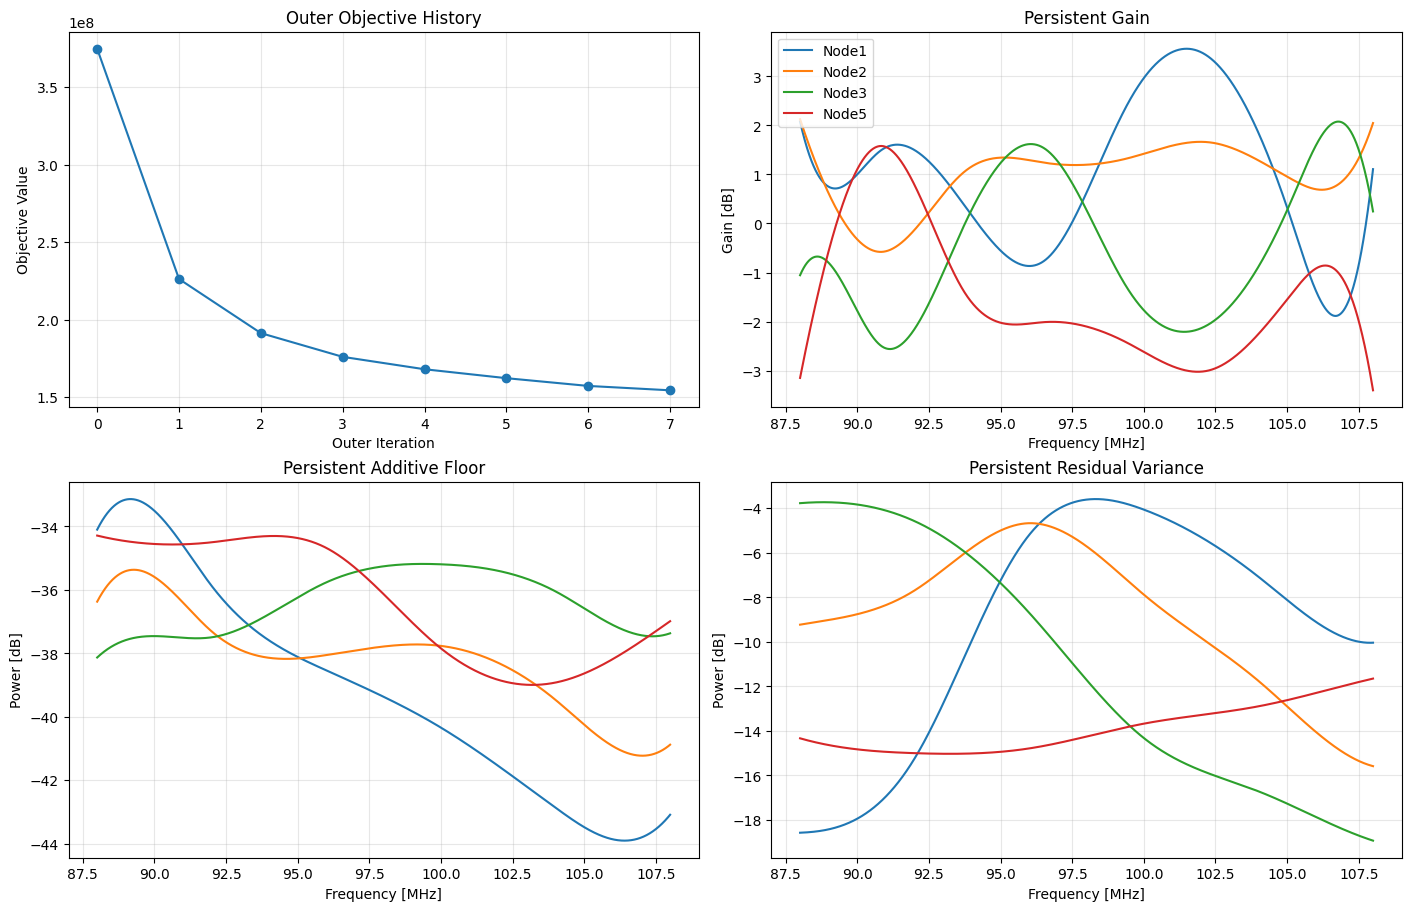

,sensor_id,mean_gain_db,mean_floor_db,mean_variance_db
0,Node1,0.974189,-39.197111,-9.173496
1,Node2,0.977065,-38.180038,-8.839688
2,Node3,-0.463377,-36.414531,-11.095991
3,Node5,-1.487877,-36.372600,-13.911970


In [ ]:
inspection_campaign = preparation.prepared_campaigns[0].campaign
frequency_mhz = inspection_campaign.frequency_hz / 1.0e6

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

axes[0, 0].plot(
    range(len(fit_result.result.objective_history)),
    fit_result.result.objective_history,
    marker="o",
)
axes[0, 0].set_title("Outer Objective History")
axes[0, 0].set_xlabel("Outer Iteration")
axes[0, 0].set_ylabel("Objective Value")
axes[0, 0].grid(alpha=0.3)

curve_rows = []
for sensor_id in fit_result.result.sensor_ids:
    curves = evaluate_persistent_calibration(
        result=fit_result.result,
        sensor_id=sensor_id,
        configuration=inspection_campaign.configuration,
        frequency_hz=inspection_campaign.frequency_hz,
    )
    axes[0, 1].plot(frequency_mhz, power_linear_to_db(curves.gain_power), label=sensor_id)
    axes[1, 0].plot(
        frequency_mhz,
        power_linear_to_db(curves.additive_noise_power),
        label=sensor_id,
    )
    axes[1, 1].plot(
        frequency_mhz,
        power_linear_to_db(curves.residual_variance_power2),
        label=sensor_id,
    )
    curve_rows.append(
        {
            "sensor_id": sensor_id,
            "mean_gain_db": float(power_linear_to_db(curves.gain_power).mean()),
            "mean_floor_db": float(power_linear_to_db(curves.additive_noise_power).mean()),
            "mean_variance_db": float(power_linear_to_db(curves.residual_variance_power2).mean()),
        }
    )

axes[0, 1].set_title("Persistent Gain")
axes[0, 1].set_xlabel("Frequency [MHz]")
axes[0, 1].set_ylabel("Gain [dB]")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(loc="best")

axes[1, 0].set_title("Persistent Additive Floor")
axes[1, 0].set_xlabel("Frequency [MHz]")
axes[1, 0].set_ylabel("Power [dB]")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_title("Persistent Residual Variance")
axes[1, 1].set_xlabel("Frequency [MHz]")
axes[1, 1].set_ylabel("Power [dB]")
axes[1, 1].grid(alpha=0.3)

plt.show()

display(pd.DataFrame(curve_rows).sort_values("sensor_id"))